In [ ]:
import pandas as pd
import matplotlib.pyplot as plt

import seaborn as sns

from sklearn.preprocessing import StandardScaler
from sklearn.cluster import KMeans
from sklearn.decomposition import PCA
import pandas as pd

In [3]:
df = pd.read_csv(r"D:\Ramesh\Project\ml-assessment- Ramesh Kumar\data\q2_customers.csv")
df.head()

,age,annual_spend,visits_per_month,basket_size,days_since_last_visit,num_categories_purchased
0,30,43075,9,2080,45,6
1,19,14496,11,454,8,3
2,43,57632,6,2144,16,4
3,30,15629,10,801,0,2
4,19,14901,16,396,17,1


In [4]:
scaler = StandardScaler()
scaled_data = scaler.fit_transform(df)

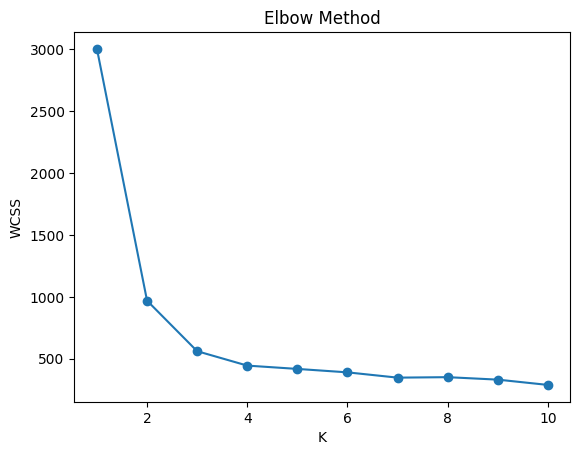

In [5]:
wcss = []

for k in range(1, 11):
    km = KMeans(n_clusters=k, random_state=42)
    km.fit(scaled_data)
    wcss.append(km.inertia_)

plt.plot(range(1, 11), wcss, marker='o')
plt.xlabel("K")
plt.ylabel("WCSS")
plt.title("Elbow Method")
plt.show()

In [6]:
kmeans = KMeans(n_clusters=3, random_state=42)
clusters = kmeans.fit_predict(scaled_data)

df['cluster'] = clusters

centroids = pd.DataFrame(
    scaler.inverse_transform(kmeans.cluster_centers_),
    columns=df.columns[:-1]
)

centroids

,age,annual_spend,visits_per_month,basket_size,days_since_last_visit,num_categories_purchased
0,24.676471,14847.370588,14.341176,558.970588,9.076471,2.111765
1,56.769697,89413.333333,2.527273,5530.545455,105.357576,7.515152
2,40.387879,43340.733333,8.193939,2021.684848,35.187879,4.424242


In [7]:
pca = PCA(n_components=2)
pca_components = pca.fit_transform(scaled_data)

print("Explained Variance Ratio:", pca.explained_variance_ratio_)

loadings = pd.DataFrame(
    pca.components_.T,
    columns=['PC1', 'PC2'],
    index=df.columns[:-1]
)

print(loadings)

Explained Variance Ratio: [0.83560354 0.05568764]
                               PC1       PC2
age                       0.411569 -0.259432
annual_spend              0.421540 -0.033270
visits_per_month         -0.410399  0.208318
basket_size               0.412012 -0.195402
days_since_last_visit     0.378582  0.911194
num_categories_purchased  0.414017 -0.140479


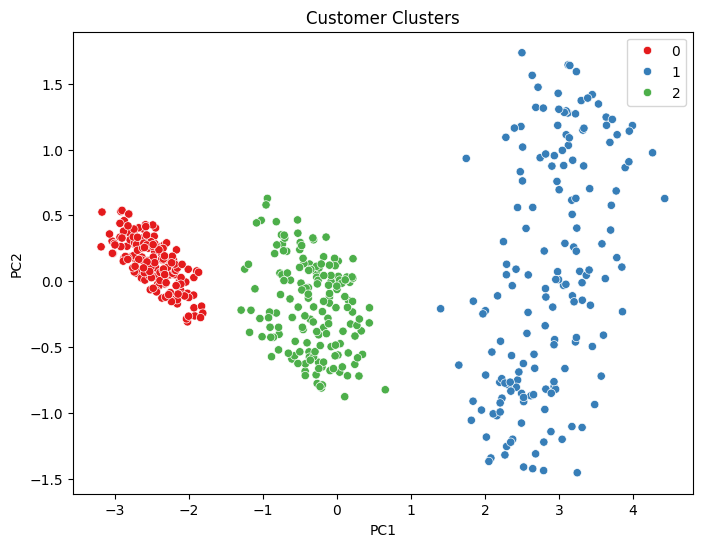

In [8]:
plt.figure(figsize=(8,6))
sns.scatterplot(
    x=pca_components[:,0],
    y=pca_components[:,1],
    hue=clusters,
    palette='Set1'
)
plt.title("Customer Clusters")
plt.xlabel("PC1")
plt.ylabel("PC2")
plt.show()